# 🧠 Supervised Contrastive Learning (SupCon)

**Part II · Embedding Architectures & Similarity Learning**

---

## 👤 Instructor

**Ing. Jesús Alan Hernández Galván**

📫 alanhernandezgalvan@icloud.com
🌐 [https://unlikeghost.github.io/](https://unlikeghost.github.io/)

---

## 🗺️ Progreso del curso

1. CNN: The Feature Extractor ✅
2. **Embedding Architectures & Similarity Learning 📍**
3. The SupCon Pipeline (Scalability & Transfer)

---

## 🎯 Objetivo del módulo
Construir la infraestructura de **Metric Learning** necesaria para proyectar datos biomédicos en un espacio latente organizado por similitud.

Este módulo marca la transición de la arquitectura MiniConvNet tradicional hacia sistemas de **pesos compartidos (Siamese Networks)**. Aprenderemos a transformar imágenes en puntos dentro de un espacio vectorial (**Embeddings**) donde la cercanía geométrica es forzada por etiquetas de clase. El enfoque será entender cómo la función de pérdida (Contrastive Loss) actúa como un arquitecto del espacio latente, preparando el terreno para el entrenamiento a gran escala y la transferencia de conocimiento de la Parte III.


In [1]:
import sys

def check_environment():
    if 'google.colab' in sys.modules:
        print("Entorno: Google Colab ☁️")

        from IPython import get_ipython
        ipython = get_ipython()
        if ipython:
            print("Instalando dependencias necesarias...")
            ipython.run_line_magic('pip', 'install --upgrade umap-learn numba')

        return "colab"
    else:
        print("Entorno: Local / Jupyter Notebook 💻")
        return "local"

env = check_environment()

Entorno: Local / Jupyter Notebook 💻


In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
import os
import logging

os.environ["TORCH_LOGS"] = "-all"
logging.getLogger("torch._inductor").setLevel(logging.ERROR)

In [4]:
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
data_path = os.path.join(project_root, "data")
models_path = os.path.join(project_root, "models")

## Librerias

In [5]:
import umap
import torch
import random
import torchvision

import numpy as np
import seaborn as sns
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

from torchsummary import summary
from sklearn.metrics import confusion_matrix

In [6]:
from src.models import MiniConvNetEncoder
from src.plot_data import show_batch, show_features, plot_latent_space_3d, plot_latent_space_2d, show_siamese_batch
from src.datasets import ContrastiveLearningDataset
from src.losses import ContrastiveLoss

## 🔒 Semilla para reproducibilidad

In [7]:
seed: int = 42
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

## ⚡ Optimización de Aceleración por Hardware (CUDA/cuDNN)

### 🚀 Verificar uso de GPU (si está disponible)

In [8]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
    )
print(f"Status: System ready on {device}")

Status: System ready on cuda


In [9]:
if device == 'cuda':
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.allow_tf32 = True

## 🧪 Implementación

### 📦 Carga y preprocesamiento de datos

A diferencia de la clasificación convencional, donde el dataset CIFAR-10 nos entrega una imagen y su categoría correspondiente para que la red aprenda a "nombrar" objetos, el aprendizaje contrastivo requiere un enfoque distinto. Para entrenar una arquitectura siamesa, necesitamos que el modelo aprenda a extraer representaciones que le permitan comparar similitudes en lugar de solo asignar etiquetas.

Dado que CIFAR-10 no está estructurado de esta manera, hemos implementado un DataLoader personalizado encargado de transformar el flujo de datos en un sistema de pares. En este esquema, el modelo recibe dos imágenes simultáneamente junto con un indicador binario: un valor de 1 si ambas imágenes pertenecen a la misma clase (par positivo) y un valor de 0 si pertenecen a categorías diferentes (par negativo). Este cambio en la preparación de los datos es lo que permite que la red pase de un aprendizaje basado en etiquetas a uno basado en la discriminación y asociación de rasgos visuales.

In [10]:
batch_size: int = 512

train_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomResizedCrop(size=(32, 32), scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225)),
])

val_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225)),
])

classes: tuple = (
    'plane', 'car', 'bird', 'cat',
    'deer', 'dog', 'frog', 'horse',
    'ship', 'truck'
)

In [11]:
test_data = torchvision.datasets.CIFAR10(
    root=data_path,
    train=False,
    download=True,
)

full_train_dataset = torchvision.datasets.CIFAR10(
    root=data_path,
    train=True,
    download=True,
)

# Definimos los tamaños (80% train, 20% val)
train_size = int(len(full_train_dataset) * .8)
val_size = int(len(full_train_dataset) - train_size)

train_size, val_size, len(test_data)

(40000, 10000, 10000)

In [12]:
train_data, val_data = torch.utils.data.random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(seed)
)

In [13]:
train_dataset = ContrastiveLearningDataset(
    dataset=train_data,
    transform=train_transform
)
val_dataset = ContrastiveLearningDataset(
    dataset=val_data,
    transform=val_transform
)

test_dataset  = ContrastiveLearningDataset(
    dataset=test_data,
    transform=val_transform
)

In [14]:
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=6,
    pin_memory=True,
    persistent_workers=True,
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=6,
    persistent_workers=True,
    pin_memory=True,
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=6,
    pin_memory=True,
    persistent_workers=True,
)

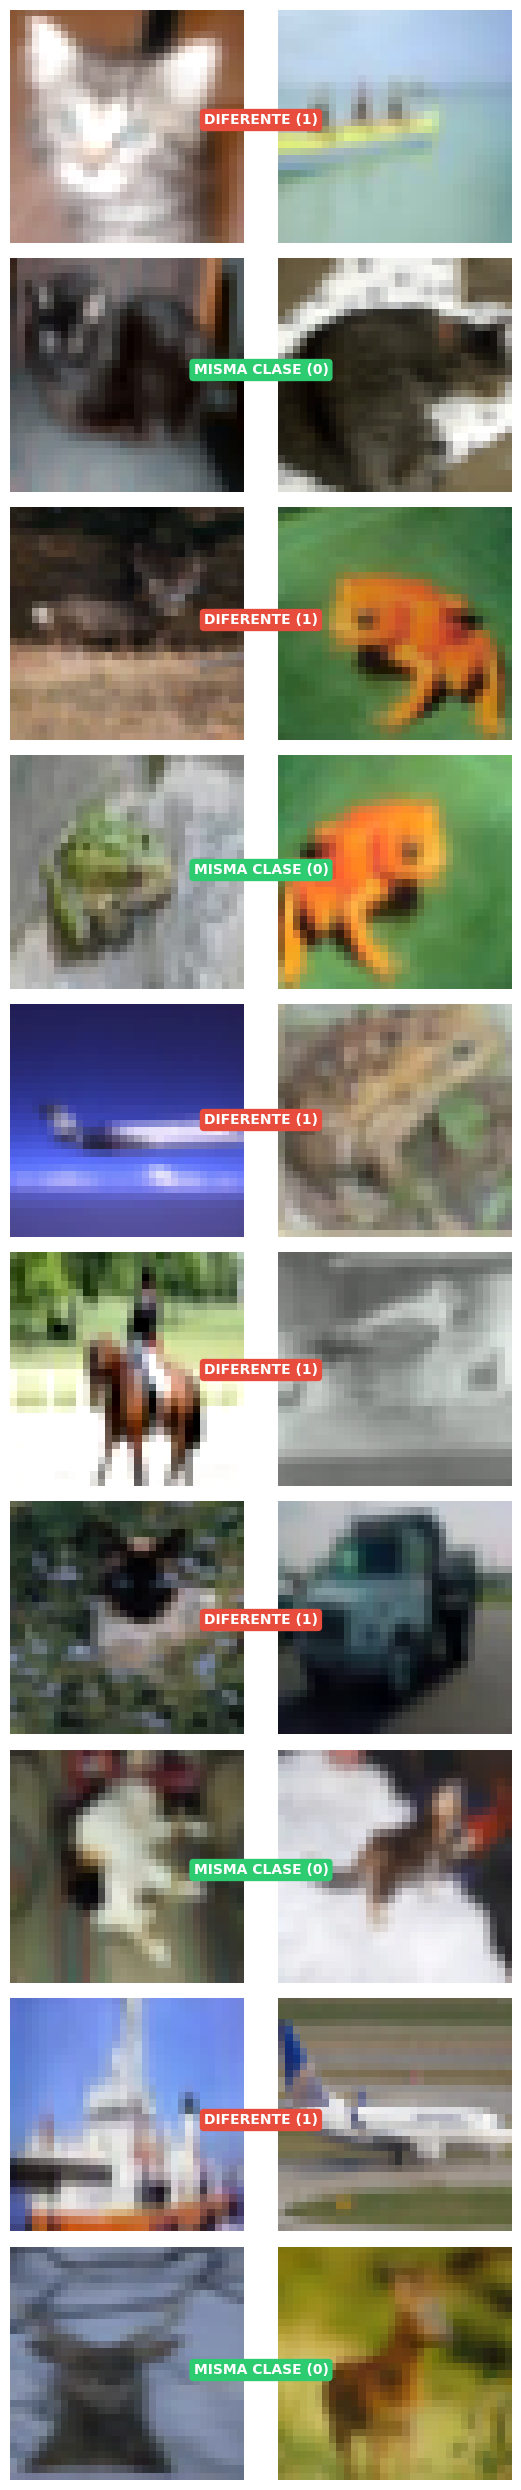

In [15]:
show_siamese_batch(
    train_loader,
    n_pairs=10
)

### 🧠 Siamese Architecture: Similarity Learning

![Siamese network](https://b2633864.smushcdn.com/2633864/wp-content/uploads/2020/11/keras_siamese_networks_process.png?lossy=2&strip=1&webp=1)


Esta arquitectura utiliza ramas gemelas con pesos compartidos para aprender a comparar en lugar de clasificar. En este paradigma, la red actúa como un cartógrafo que proyecta imágenes en un espacio geométrico donde la distancia dicta la relación semántica: si dos objetos se parecen, sus vectores deben colisionar; si son distintos, deben repelerse.

Es la base de tecnologías como FaceID y sistemas de recomendación visual, ya que permite extraer Embeddings (huellas digitales numéricas) que capturan la esencia de los datos sin depender de etiquetas rígidas. Este "mapeo inteligente" es el puente técnico hacia el aprendizaje autosupervisado, donde la red aprende a organizarse sola explorando la estructura interna de las imágenes.

In [16]:
output_dim: int = 256
model = MiniConvNetEncoder(output_dim=output_dim).to(device)
print(model)
summary(model, input_size=(3, 32, 32))

MiniConvNetEncoder(
  (feature_extractor): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (projector): Sequential(
    (0): Linear(in_features=4096, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
  )
)
----------------------------------------------------------------
        Layer (type)               Output Shap

### ⚙️ Proceso de entrenamiento

La pérdida de contraste es una función fundamental en redes siamesas cuyo objetivo es estructurar el espacio latente a partir de relaciones de similitud. En lugar de clasificar directamente, el modelo aprende una métrica: acerca representaciones de pares similares y separa aquellas que pertenecen a clases distintas.

![Contrastive Loss Equation](https://i.sstatic.net/ziIOH.png)

Este enfoque se basa en pares de datos etiquetados como “similares” o “diferentes”. Para los pares positivos, la pérdida penaliza distancias grandes, incentivando que sus embeddings colapsen en regiones cercanas. Para los pares negativos, en cambio, empuja las representaciones a separarse al menos hasta un margen definido, evitando que el modelo distinga innecesariamente ejemplos ya bien separados.

![Latent Space Example](https://ars.els-cdn.com/content/image/1-s2.0-S0169716123000032-f04-02-9780443184307.jpg)


In [17]:
num_epochs: int = 50
criterion = ContrastiveLoss(pos_margin=0, neg_margin=1.0).to(device)
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs * len(train_loader),
    eta_min=1e-6
)

In [18]:
train_loss, val_loss = [], []
train_dist_pos, val_dist_pos = [], []
train_dist_neg, val_dist_neg = [], []

for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    model.train()
    running_loss, running_dist_pos, running_dist_neg = 0.0, 0.0, 0.0
    pos_count, neg_count = 0, 0

    for img1, img2, target in train_loader:
        img1, img2, target = img1.to(device), img2.to(device), target.to(device)
        target = target.squeeze().float()

        optimizer.zero_grad()
        emb1, emb2 = model(img1), model(img2)
        loss = criterion(emb1, emb2, target)  # label: 0=similar, 1=diferente
        loss.backward()
        optimizer.step()
        scheduler.step()

        with torch.no_grad():
            distances = F.pairwise_distance(emb1, emb2, eps=1e-6)
            pos_mask = (target == 0)
            neg_mask = (target == 1)
            if pos_mask.any():
                running_dist_pos += distances[pos_mask].mean().item()
                pos_count += 1
            if neg_mask.any():
                running_dist_neg += distances[neg_mask].mean().item()
                neg_count += 1

        running_loss += loss.item()

    # --- VALIDATION PHASE ---
    model.eval()
    v_running_loss, v_running_dist_pos, v_running_dist_neg = 0.0, 0.0, 0.0
    v_pos_count, v_neg_count = 0, 0

    with torch.no_grad():
        for img1, img2, target in val_loader:
            img1, img2, target = img1.to(device), img2.to(device), target.to(device)
            target = target.squeeze().float()

            emb1, emb2 = model(img1), model(img2)
            loss = criterion(emb1, emb2, target)

            distances = F.pairwise_distance(emb1, emb2, eps=1e-6)
            pos_mask = (target == 0)
            neg_mask = (target == 1)
            if pos_mask.any():
                v_running_dist_pos += distances[pos_mask].mean().item()
                v_pos_count += 1
            if neg_mask.any():
                v_running_dist_neg += distances[neg_mask].mean().item()
                v_neg_count += 1

            v_running_loss += loss.item()

    # --- Métricas finales del epoch ---
    train_loss.append(running_loss / len(train_loader))
    train_dist_pos.append(running_dist_pos / pos_count if pos_count > 0 else 0)
    train_dist_neg.append(running_dist_neg / neg_count if neg_count > 0 else 0)

    val_loss.append(v_running_loss / len(val_loader))
    val_dist_pos.append(v_running_dist_pos / v_pos_count if v_pos_count > 0 else 0)
    val_dist_neg.append(v_running_dist_neg / v_neg_count if v_neg_count > 0 else 0)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss T/V: {train_loss[-1]:.4f}/{val_loss[-1]:.4f} | "
          f"Dist+ T/V: {train_dist_pos[-1]:.4f}/{val_dist_pos[-1]:.4f} | "
          f"Dist- T/V: {train_dist_neg[-1]:.4f}/{val_dist_neg[-1]:.4f}")

Epoch [1/50] | Loss T/V: 0.2276/0.2033 | Dist+ T/V: 0.4457/0.3713 | Dist- T/V: 0.5719/0.5503
Epoch [2/50] | Loss T/V: 0.2002/0.1865 | Dist+ T/V: 0.4153/0.3694 | Dist- T/V: 0.6001/0.6037
Epoch [3/50] | Loss T/V: 0.1907/0.1882 | Dist+ T/V: 0.4059/0.3819 | Dist- T/V: 0.6244/0.6115
Epoch [4/50] | Loss T/V: 0.1848/0.1790 | Dist+ T/V: 0.3991/0.3651 | Dist- T/V: 0.6357/0.6409
Epoch [5/50] | Loss T/V: 0.1777/0.1700 | Dist+ T/V: 0.3868/0.3719 | Dist- T/V: 0.6497/0.6746
Epoch [6/50] | Loss T/V: 0.1758/0.1785 | Dist+ T/V: 0.3839/0.3670 | Dist- T/V: 0.6533/0.6414
Epoch [7/50] | Loss T/V: 0.1706/0.1686 | Dist+ T/V: 0.3757/0.3568 | Dist- T/V: 0.6631/0.6579
Epoch [8/50] | Loss T/V: 0.1685/0.1670 | Dist+ T/V: 0.3708/0.3444 | Dist- T/V: 0.6647/0.6525
Epoch [9/50] | Loss T/V: 0.1681/0.1619 | Dist+ T/V: 0.3718/0.3556 | Dist- T/V: 0.6699/0.6805
Epoch [10/50] | Loss T/V: 0.1644/0.1601 | Dist+ T/V: 0.3672/0.3448 | Dist- T/V: 0.6793/0.6737
Epoch [11/50] | Loss T/V: 0.1626/0.1638 | Dist+ T/V: 0.3629/0.3625 | 

In [19]:
torch.save(
    model.state_dict(),
    os.path.join(models_path, "MiniConv_siamese.pth")
)

### 📊 Métricas de entrenamiento y validación

#### 📊 Entrenamiento

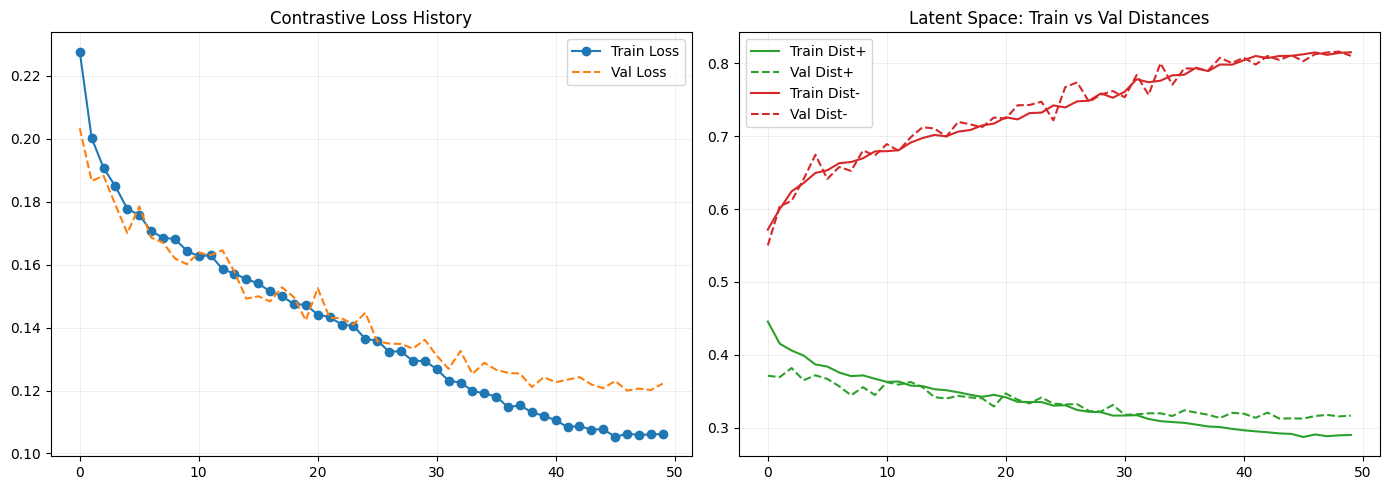

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# 1. Pérdida (Contrastive Loss)
axs[0].plot(train_loss, label='Train Loss', color='#1f77b4', marker='o')
axs[0].plot(val_loss, label='Val Loss', color='#ff7f0e', linestyle='--')
axs[0].set_title('Contrastive Loss History')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# 2. Distancias Euclidiana (Similitud)
axs[1].plot(train_dist_pos, label='Train Dist+', color='#2ca02c')
axs[1].plot(val_dist_pos, label='Val Dist+', color='#2ca02c', linestyle='--')
axs[1].plot(train_dist_neg, label='Train Dist-', color='#d62728')
axs[1].plot(val_dist_neg, label='Val Dist-', color='#d62728', linestyle='--')
axs[1].set_title('Latent Space: Train vs Val Distances')
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### 📊 Validación

In [21]:
model.eval()
all_preds = []
all_labels = []

# Umbral de distancia: menor a esto es IGUAL (0)
threshold = 0.5

with torch.no_grad():
    for img1, img2, target in test_loader:
        img1, img2, target = img1.to(device), img2.to(device), target.to(device)

        # 1. Obtener embeddings
        emb1 = model(img1)
        emb2 = model(img2)

        # 2. Distancia euclidiana
        distancia = F.pairwise_distance(emb1, emb2)

        # 3. Predicción: 0 si son iguales (dist < umbral), 1 si son diferentes
        # La condición (dist >= threshold) marca como 1 los que superan el umbral
        predicted = (distancia >= threshold).int()

        # 4. Etiquetas reales (0: Igual, 1: Diferente)
        target_labels = target.view(-1).int()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(target_labels.cpu().numpy())

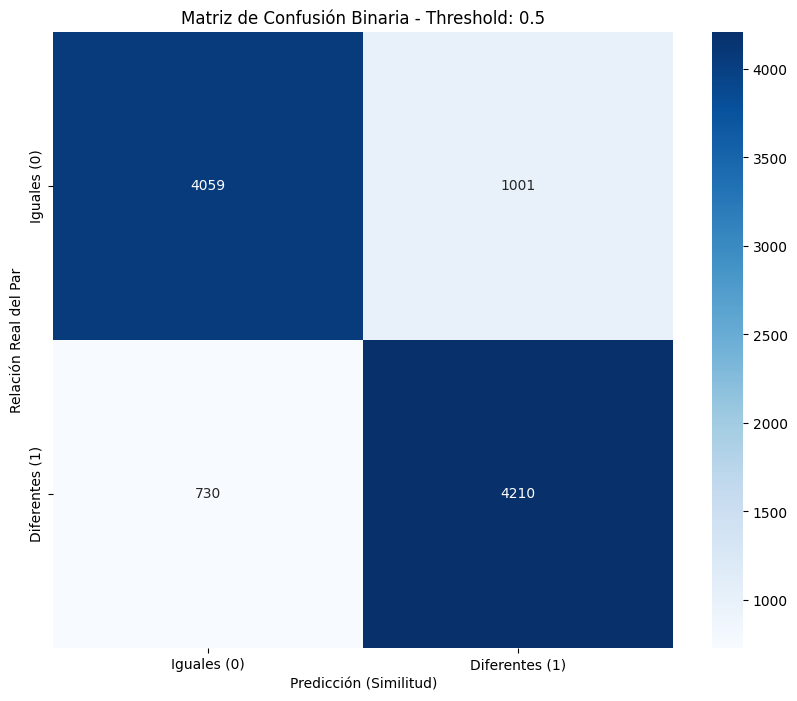

In [22]:
cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Iguales (0)', 'Diferentes (1)'],
            yticklabels=['Iguales (0)', 'Diferentes (1)'])

plt.xlabel('Predicción (Similitud)')
plt.ylabel('Relación Real del Par')
plt.title(f'Matriz de Confusión Binaria - Threshold: {threshold}')
plt.show()

### 🔍 Visualización de features

#### 🧩 Feature Maps

In [23]:
model.eval()

images_batch, _, labels_batch = next(iter(test_loader))
images_batch = images_batch.to(device)

images_batch = images_batch[0:5, :, :, :]

with torch.no_grad():
    # Extraer features de la PRIMERA capa (índice 0 es Conv1, índice 1 es ReLU)
    # Pasamos solo por las primeras 2 capas del bloque
    features_conv1 = model.feature_extractor[:2](images_batch)

    # Extraer features de la SEGUNDA capa (índice 3 es Conv2, índice 4 es ReLU)
    # Pasamos por las primeras 5 capas del bloque
    features_conv2 = model.feature_extractor[:5](images_batch)


images_np = images_batch.cpu().numpy()
feat1_np = features_conv1.cpu().numpy() # Forma: (32, 6, 28, 28)
feat2_np = features_conv2.cpu().numpy() # Forma: (32, 16, 10, 10)

feat1_np.shape, feat2_np.shape

((5, 32, 32, 32), (5, 64, 16, 16))

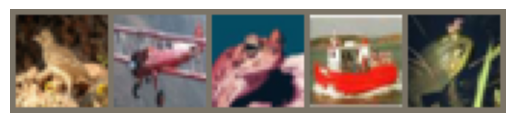

Canal 0


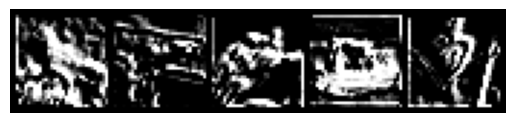

Canal 1


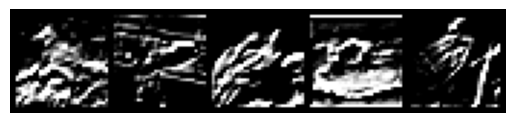

Canal 2


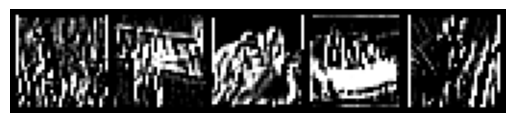

Canal 3


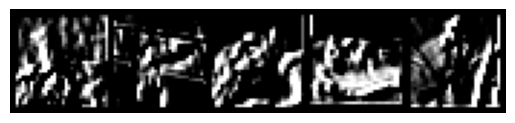

Canal 4


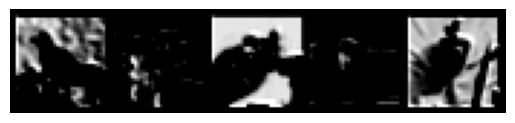

Canal 5


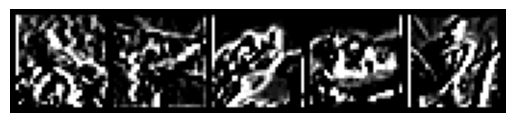

Canal 0


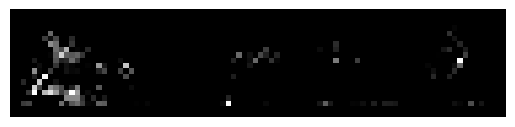

Canal 1


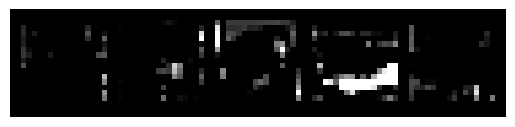

Canal 2


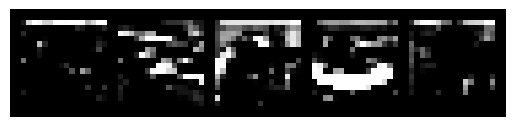

Canal 3


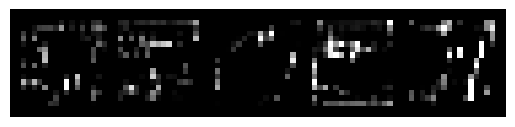

Canal 4


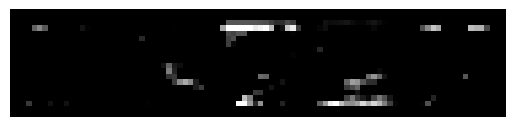

Canal 5


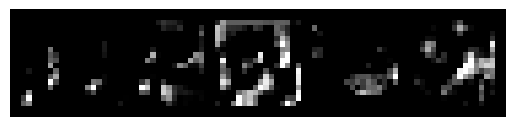

Canal 6


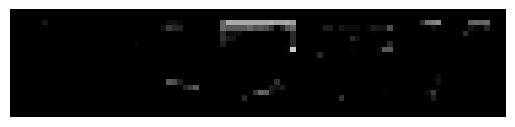

Canal 7


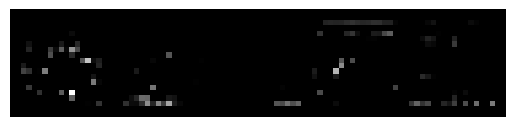

Canal 8


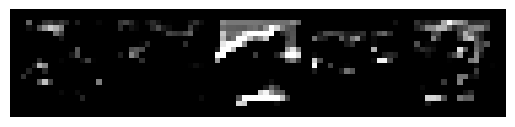

Canal 9


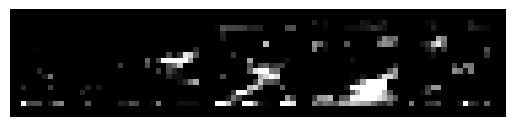

Canal 10


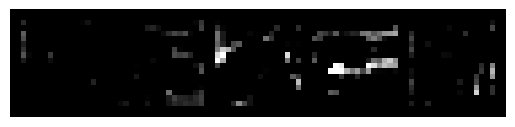

Canal 11


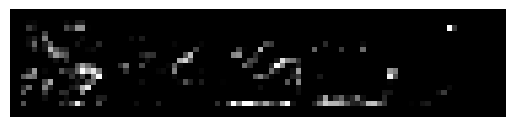

Canal 12


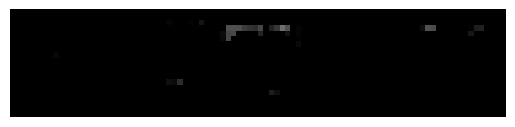

Canal 13


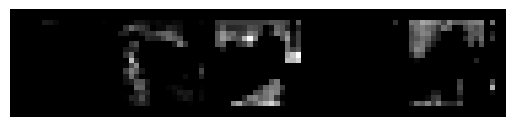

Canal 14


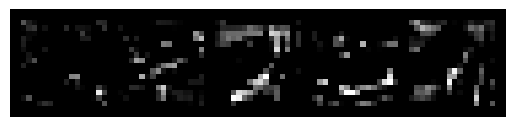

Canal 15


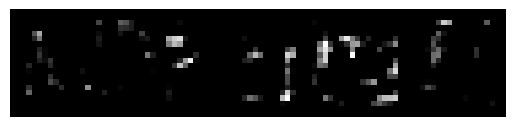

In [24]:
show_batch(
    torchvision.utils.make_grid(images_batch.to('cpu')),
)

for i in range(0, 6):
  print(f"Canal {i}")
  show_features(features_conv1, filter_index=i)

for i in range(0, 16):
  print(f"Canal {i}")
  show_features(features_conv2, filter_index=i)

#### 🧩 Proyección del espacio latente

In [25]:
# Creamos un loader sencillo que solo dé (imagen, clase_real)

simple_test_dataset = torchvision.datasets.CIFAR10(
    root=data_path,
    train=False,
    download=True,
    transform=val_transform
)
simple_test_loader = torch.utils.data.DataLoader(
    simple_test_dataset,
    batch_size=32,
)

In [26]:
model.eval()

all_embeddings = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in simple_test_loader:
        images = images.to(device)

        # Extraemos el embedding
        embedding = model(images)

        all_embeddings.append(embedding.cpu().numpy())
        all_labels.append(labels.numpy())

# Concatenamos todo en un solo array gigante
all_features = np.concatenate(all_embeddings, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

all_features.shape, all_labels.shape

((10000, 256), (10000,))

##### 🧩 3D

In [27]:
umap_embeddings = umap.UMAP(
    n_components=3,
    random_state=seed
).fit_transform(all_features)

In [28]:
plot_latent_space_3d(
    umap_embeddings,
    all_labels,
    classes
)

##### 🧩 2D

In [29]:
umap_embeddings_2d = umap.UMAP(
    n_components=2,
    random_state=seed
).fit_transform(all_features)
umap_embeddings_2d.shape

(10000, 2)

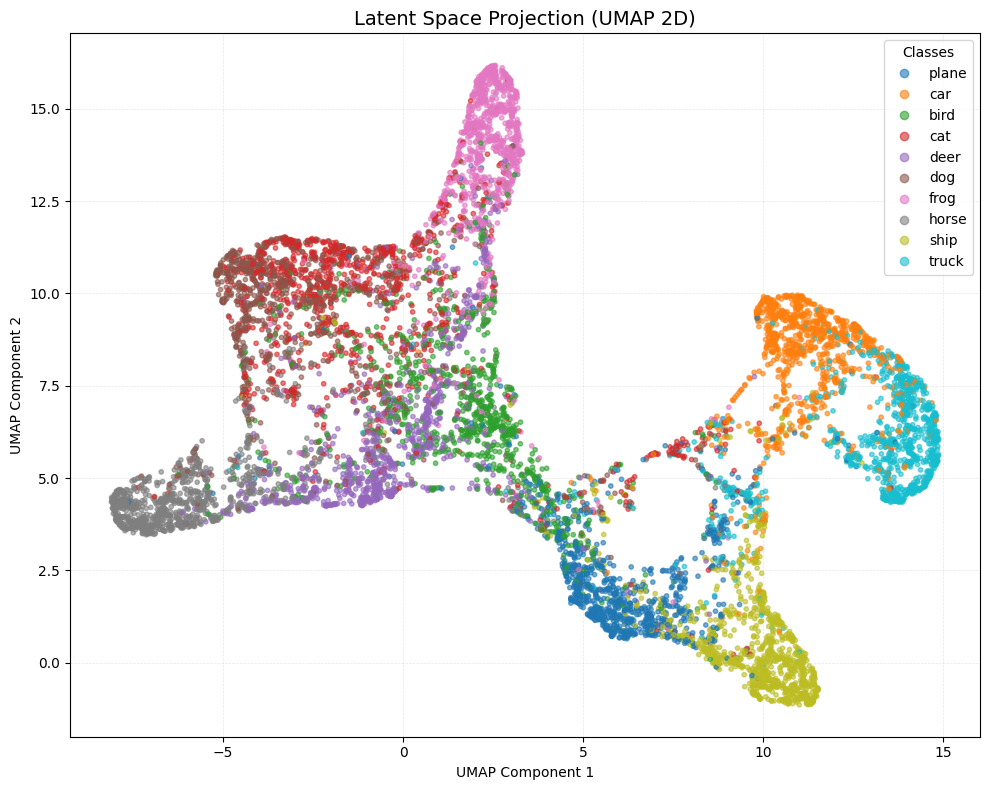

In [30]:
plot_latent_space_2d(
    umap_embeddings_2d,
    all_labels,
    classes
)